In [1]:
%matplotlib inline

import torch
from torch import nn
from d2l import torch as d2l

In [2]:
# Factor Scheduler

class FactorScheduler:
    
    def __init__(
        self,
        factor: float = 1.0,
        stop_learning_rate: float = 1e-7,
        base_learning_rate: float = 1e-1,
    ) -> None: 
        self.factor = factor
        self.stop_learning_rate = (
            stop_learning_rate
        )
        self.base_learning_rate = (
            base_learning_rate
        )
        
    def __call__(
        self,
        _num_updates: int,
    ) -> float:
        
        # η(t + 1) = max(
        #     η_min,
        #     η(t) * α,
        # )
        self.base_learning_rate = max(
            self.stop_learning_rate,
            self.base_learning_rate * self.factor,
        )
        
        return self.base_learning_rate

First Learning Rate: 1.8
Final Learning Rate: 0.01030755041464024
Minimum Allowed: 0.01


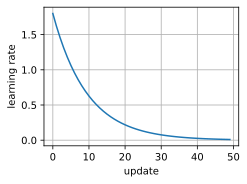

In [3]:
# Multiplicative Decay 시각화

num_updates = 50

scheduler = FactorScheduler(
    factor=0.9,
    stop_learning_rate=1e-2,
    base_learning_rate=2.0,
)

updates = torch.arange(
    num_updates
)

learning_rates = [
    scheduler(update)
    for update in range(num_updates)
]

d2l.plot(
    updates,
    learning_rates,
    xlabel="update",
    ylabel="learning rate",
)

print(
    "First Learning Rate:",
    learning_rates[0],
)
print(
    "Final Learning Rate:",
    learning_rates[-1],
)
print(
    "Minimum Allowed:",
    scheduler.stop_learning_rate,
)